In [2]:
import pandas as pd

df = pd.read_csv("songs_normalize.csv")

df.head()

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            2000 non-null   str    
 1   song              2000 non-null   str    
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   year              2000 non-null   int64  
 5   popularity        2000 non-null   int64  
 6   danceability      2000 non-null   float64
 7   energy            2000 non-null   float64
 8   key               2000 non-null   int64  
 9   loudness          2000 non-null   float64
 10  mode              2000 non-null   int64  
 11  speechiness       2000 non-null   float64
 12  acousticness      2000 non-null   float64
 13  instrumentalness  2000 non-null   float64
 14  liveness          2000 non-null   float64
 15  valence           2000 non-null   float64
 16  tempo             2000 non-null   float64
 17  genre 

In [4]:
df.isnull().sum()

artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
dtype: int64

In [5]:
df.shape

(2000, 18)

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

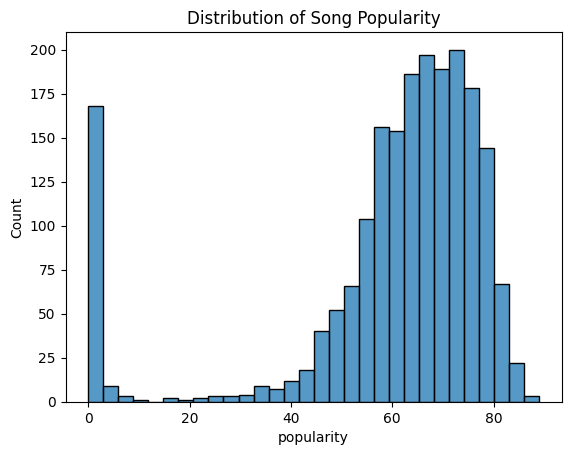

In [10]:
sns.histplot(df['popularity'], bins=30)
plt.title("Distribution of Song Popularity")
plt.show()


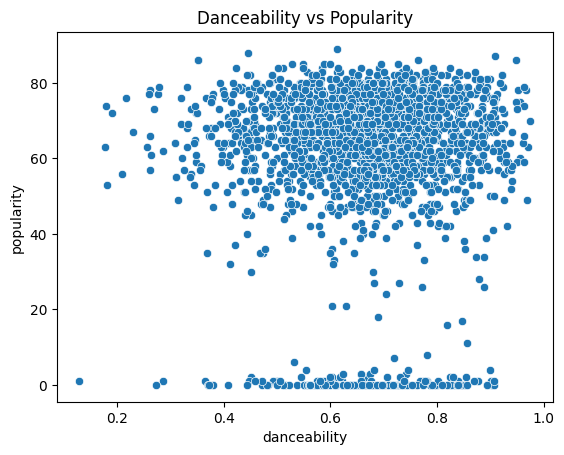

In [11]:
sns.scatterplot(x='danceability', y='popularity', data=df)
plt.title("Danceability vs Popularity")
plt.show()

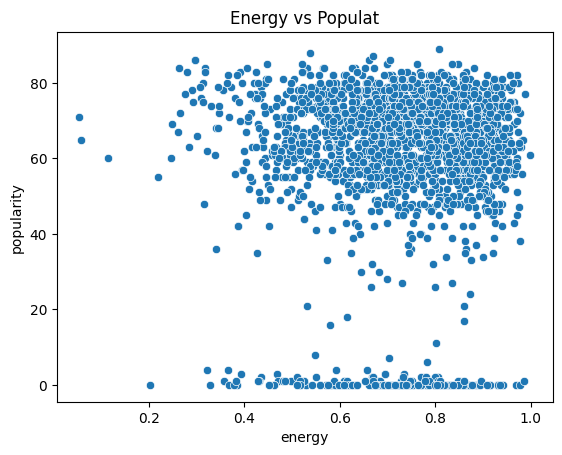

In [12]:
sns.scatterplot(x ='energy', y ='popularity', data=df)
plt.title("Energy vs Populat")
plt.show()

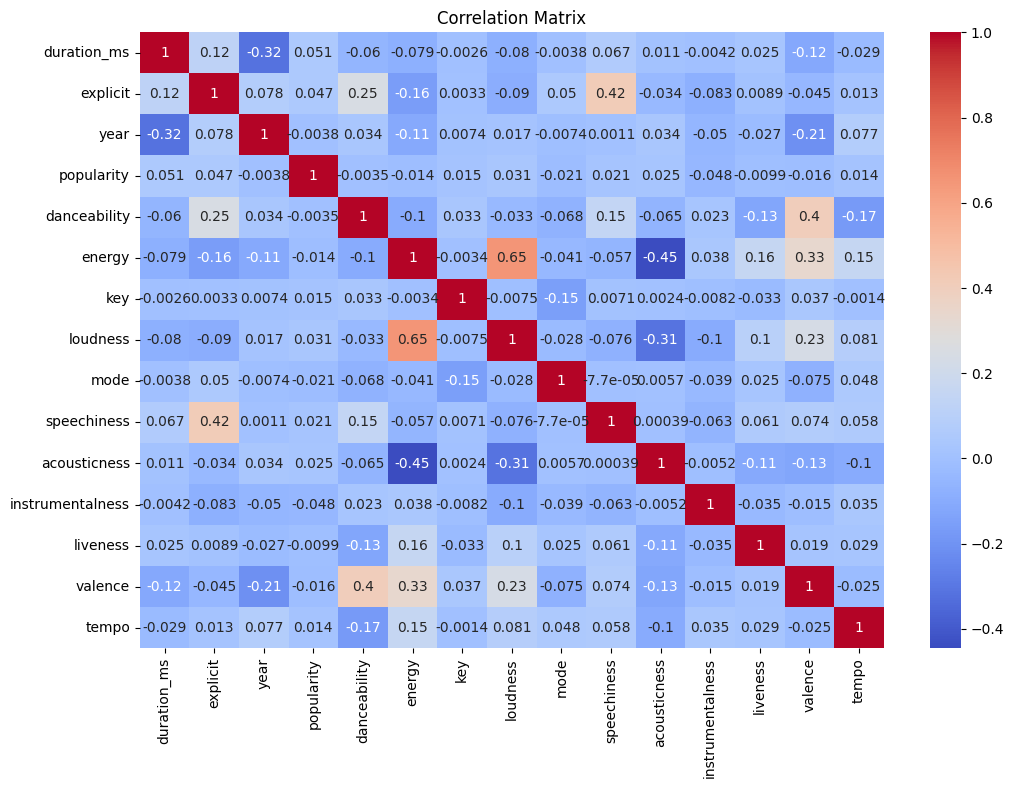

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

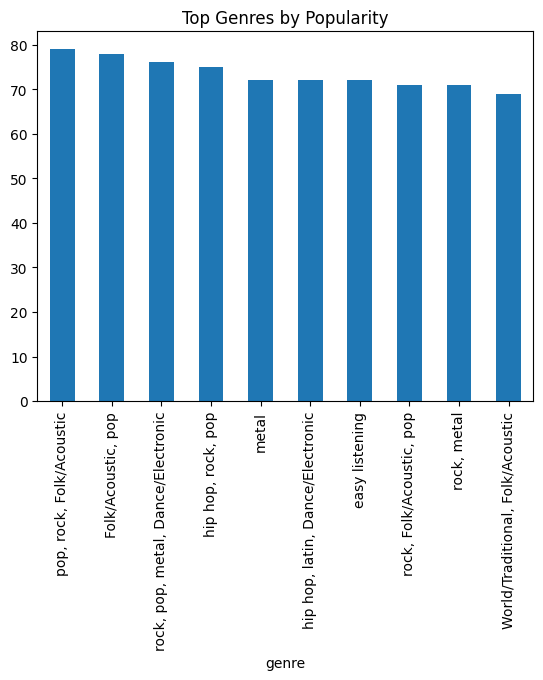

In [14]:
top_genres = df.groupby('genre')['popularity'].mean().sort_values(ascending=False)

top_genres.head(10).plot(kind='bar')
plt.title("Top Genres by Popularity")
plt.show()

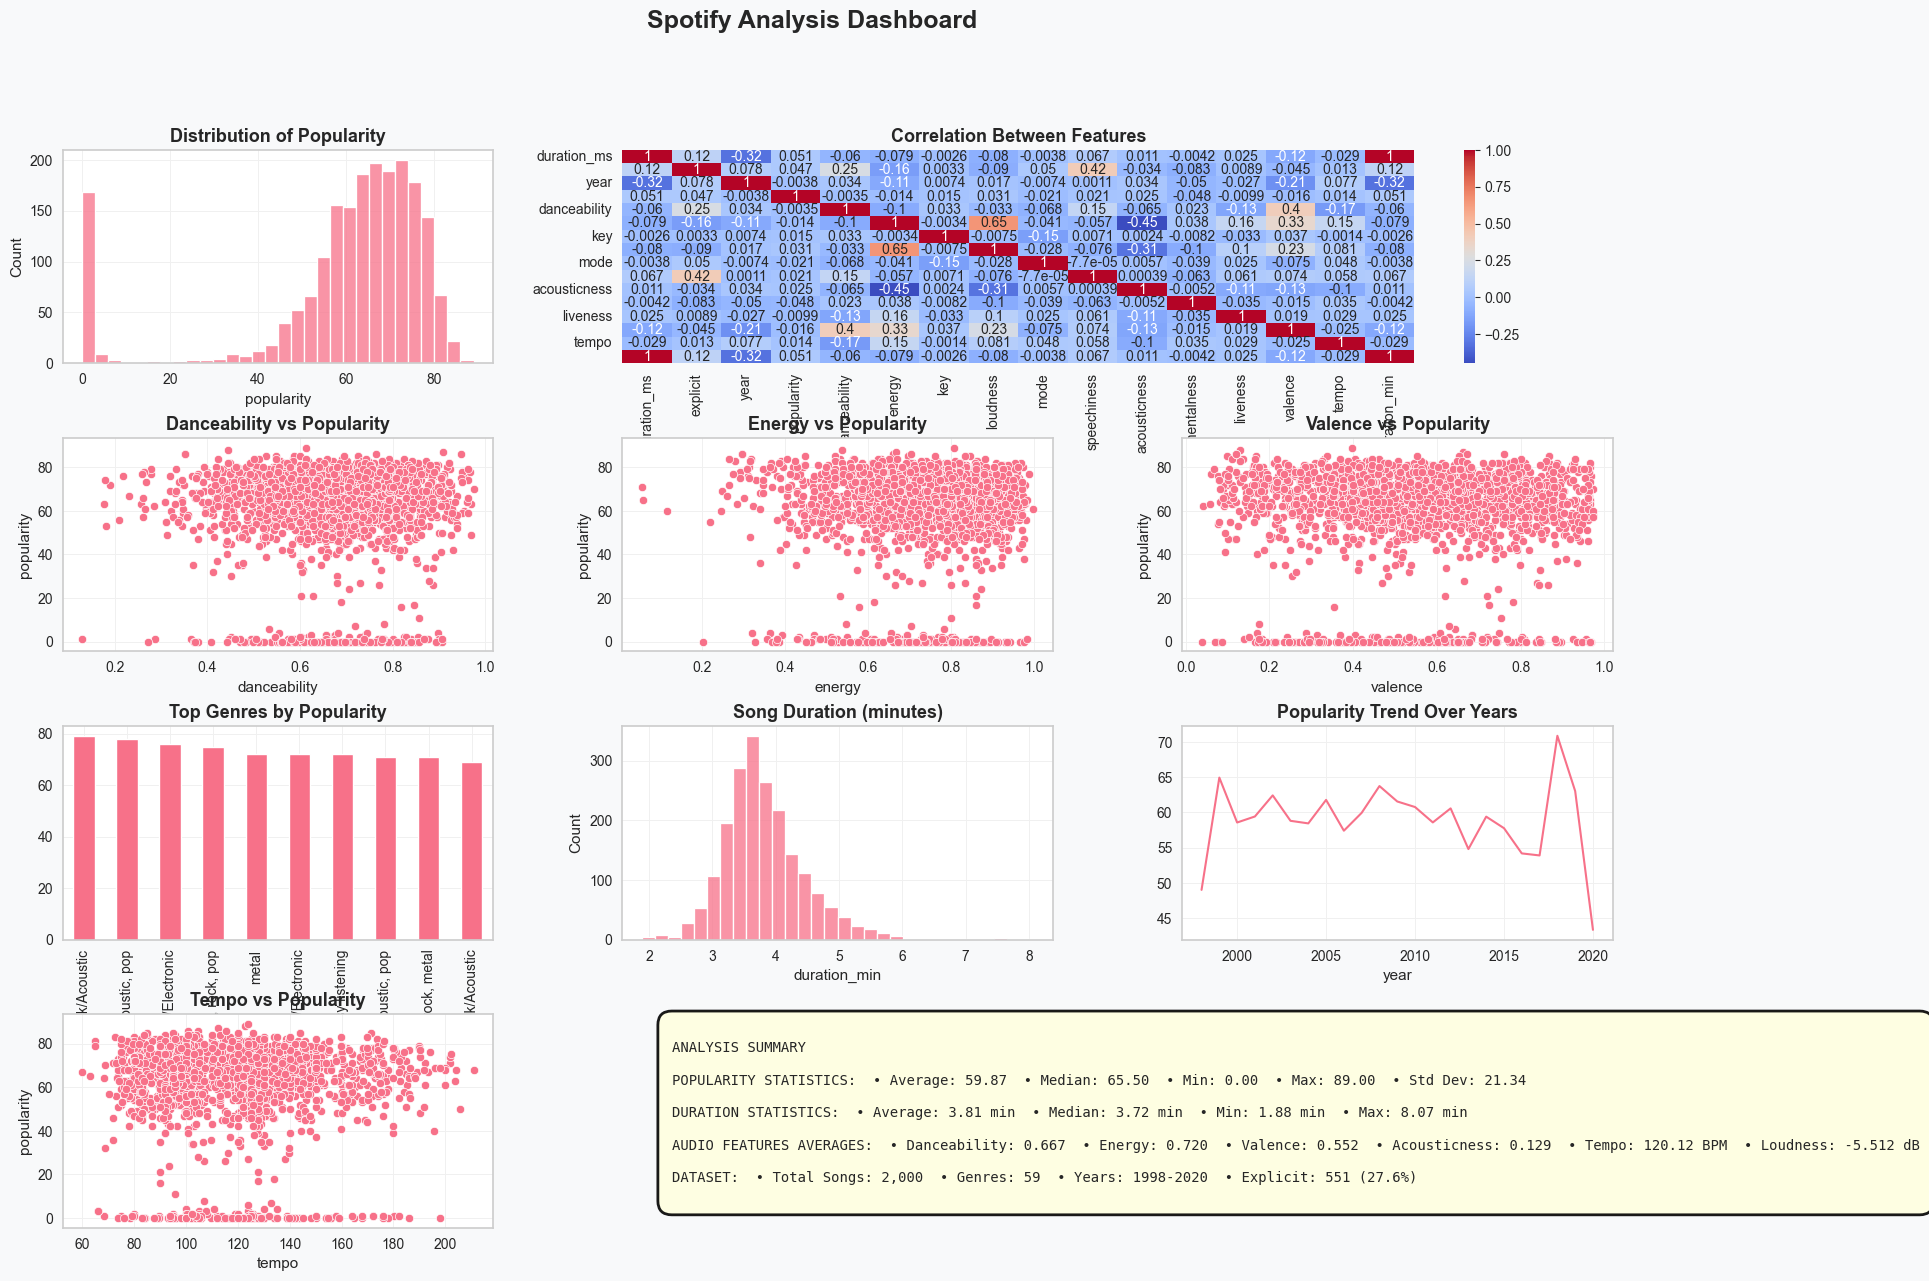

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("songs_normalize.csv")
df['duration_min'] = df['duration_ms'] / 60000

# Create dashboard
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

fig.suptitle('Spotify Analysis Dashboard', fontsize=18, fontweight='bold')

# Plot 1
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df['popularity'], bins=30, ax=ax1)
ax1.set_title("Distribution of Popularity")

# Plot 2
ax2 = fig.add_subplot(gs[0, 1:])
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", ax=ax2)
ax2.set_title("Correlation Between Features")

# Plot 3
ax3 = fig.add_subplot(gs[1, 0])
sns.scatterplot(x='danceability', y='popularity', data=df, ax=ax3)
ax3.set_title("Danceability vs Popularity")

# Plot 4
ax4 = fig.add_subplot(gs[1, 1])
sns.scatterplot(x='energy', y='popularity', data=df, ax=ax4)
ax4.set_title("Energy vs Popularity")

# Plot 5
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(x='valence', y='popularity', data=df, ax=ax5)
ax5.set_title("Valence vs Popularity")

# Plot 6
ax6 = fig.add_subplot(gs[2, 0])
top_genres = df.groupby('genre')['popularity'].mean().sort_values(ascending=False).head(10)
top_genres.plot(kind='bar', ax=ax6)
ax6.set_title("Top Genres by Popularity")

# Plot 7
ax7 = fig.add_subplot(gs[2, 1])
sns.histplot(df['duration_min'], bins=30, ax=ax7)
ax7.set_title("Song Duration (minutes)")

# Plot 8
ax8 = fig.add_subplot(gs[2, 2])
df.groupby('year')['popularity'].mean().plot(ax=ax8)
ax8.set_title("Popularity Trend Over Years")

# Plot 9
ax9 = fig.add_subplot(gs[3, 0])
sns.scatterplot(x='tempo', y='popularity', data=df, ax=ax9)
ax9.set_title("Tempo vs Popularity")

# Summary Statistics Block
ax10 = fig.add_subplot(gs[3, 1:])
ax10.axis('off')

summary_text = f"""
ANALYSIS SUMMARY

POPULARITY STATISTICS:  • Average: {df['popularity'].mean():.2f}  • Median: {df['popularity'].median():.2f}  • Min: {df['popularity'].min():.2f}  • Max: {df['popularity'].max():.2f}  • Std Dev: {df['popularity'].std():.2f}

DURATION STATISTICS:  • Average: {df['duration_min'].mean():.2f} min  • Median: {df['duration_min'].median():.2f} min  • Min: {df['duration_min'].min():.2f} min  • Max: {df['duration_min'].max():.2f} min

AUDIO FEATURES AVERAGES:  • Danceability: {df['danceability'].mean():.3f}  • Energy: {df['energy'].mean():.3f}  • Valence: {df['valence'].mean():.3f}  • Acousticness: {df['acousticness'].mean():.3f}  • Tempo: {df['tempo'].mean():.2f} BPM  • Loudness: {df['loudness'].mean():.3f} dB

DATASET:  • Total Songs: {len(df):,}  • Genres: {df['genre'].nunique()}  • Years: {df['year'].min()}-{df['year'].max()}  • Explicit: {df['explicit'].sum():,} ({df['explicit'].sum()/len(df)*100:.1f}%)
"""

ax10.text(0.05, 0.95, summary_text, transform=ax10.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, pad=1, edgecolor='black', linewidth=2))

plt.savefig('spotify_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()